# Seasonal Agriculture Performance Analysis

## VOIS AICTE Batch 1 2026–2027

**Project Type:** Major Project  
**Student Name:** Harsha Rathi  
**College:** SGSITS, Indore  
**Technology:** Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy

### Project Overview

This project analyzes agricultural data across different seasons,
crops, states, irrigation methods, environmental conditions,
resource usage, production, and economic performance.

The purpose is to identify meaningful seasonal patterns,
compare agricultural performance, and develop
evidence-based insights and recommendations.

## Problem Statement

Agricultural activities are influenced by seasonal variations
in environmental conditions, farming practices, resource
availability, and market conditions.

As a result, agricultural performance may differ from one
season to another.

The problem is to analyze the given agricultural dataset
and investigate seasonal differences in agricultural
performance by identifying meaningful patterns, trends,
relationships, and variations within the available data.

## Objectives

1. Explore and understand the agricultural dataset.
2. Clean and prepare the data for analysis.
3. Examine agricultural performance across seasons.
4. Compare yield, production, revenue, cost, and profit.
5. Analyze the relationship between environmental
   conditions and agricultural outcomes.
6. Compare crops, states, and irrigation methods.
7. Apply appropriate statistical and visualization techniques.
8. Interpret findings based on evidence from the dataset.
9. Develop meaningful conclusions and recommendations.

In [33]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from IPython.display import display

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("All libraries imported successfully.")

All libraries imported successfully.


In [34]:
# Load the agricultural dataset

DATA_PATH = "seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(DATA_PATH)

# Create one working DataFrame
data = df.copy()

print("Dataset loaded successfully!")
print("Shape of dataset:", data.shape)

display(data.head())

Dataset loaded successfully!
Shape of dataset: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [35]:
# Basic information about the dataset

print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

print("\nColumn names:")
print(data.columns.tolist())

print("\nData types:")
display(data.dtypes)

print("\nDataset information:")
data.info()

Number of rows: 4000
Number of columns: 28

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data types:


Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha            

In [36]:
# Statistical summary of numerical columns

display(data.describe().T)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.00,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,3952.00,601.15,288.93,80.00,370.20,582.00,834.95,1395.20
Avg_Temperature_C,4000.00,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.00,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,4000.00,7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,4000.00,6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,3960.00,26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,4000.00,120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,4000.00,57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,4000.00,104.76,27.74,30.00,86.20,105.10,123.60,200.00


# Data cleaning and preparation

In [37]:
# Check missing values

missing_values = data.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(data)) * 100
})

display(missing_summary[missing_summary["Missing Values"] > 0])

# Check duplicate rows
duplicate_count = data.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

,Missing Values,Missing Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


Number of duplicate rows: 0


In [38]:
# Remove duplicate rows
data = data.drop_duplicates().copy()

# Identify numerical and categorical columns
numeric_columns = data.select_dtypes(
    include=np.number
).columns

categorical_columns = data.select_dtypes(
    include="object"
).columns

# Fill numerical missing values with median
for col in numeric_columns:
    data[col] = data[col].fillna(data[col].median())

# Fill categorical missing values with mode
for col in categorical_columns:
    if data[col].isnull().any():
        data[col] = data[col].fillna(data[col].mode()[0])

print("Data cleaning completed.")
print("Cleaned dataset shape:", data.shape)
print("Remaining missing values:", data.isnull().sum().sum())
print("Remaining duplicate rows:", data.duplicated().sum())

Data cleaning completed.
Cleaned dataset shape: (4000, 28)
Remaining missing values: 0
Remaining duplicate rows: 0


In [39]:
# Check important categorical columns

for col in ["Season", "Crop", "State", "Irrigation_Method"]:
    print(f"\n{col}:")
    print(data[col].value_counts())


Season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Crop:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

State:
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

Irrigation_Method:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


## Key Analytical Questions

1. How does agricultural yield vary across seasons?
2. Which season has the highest average profit?
3. Which crops perform best in terms of yield and profit?
4. How does irrigation method affect agricultural performance?
5. Which states show higher average yield?
6. What is the relationship between rainfall and yield?
7. What is the relationship between fertilizer use and yield?
8. How does disease and pest risk vary across seasons?
9. Are there statistically significant differences in yield
   across seasons?
10. What recommendations can be developed from the findings?

# Exploratory data analysis

,Number of Records
Season,
Kharif,1779
Rabi,1627
Zaid,594


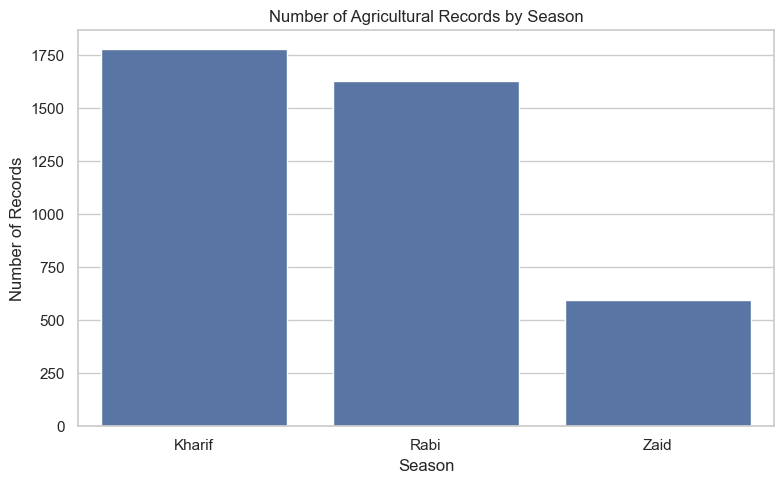

In [40]:
# Distribution of records across seasons

season_counts = data["Season"].value_counts()

display(season_counts.to_frame("Number of Records"))

plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="Season",
    order=season_counts.index
)

plt.title("Number of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

,Number of Records
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


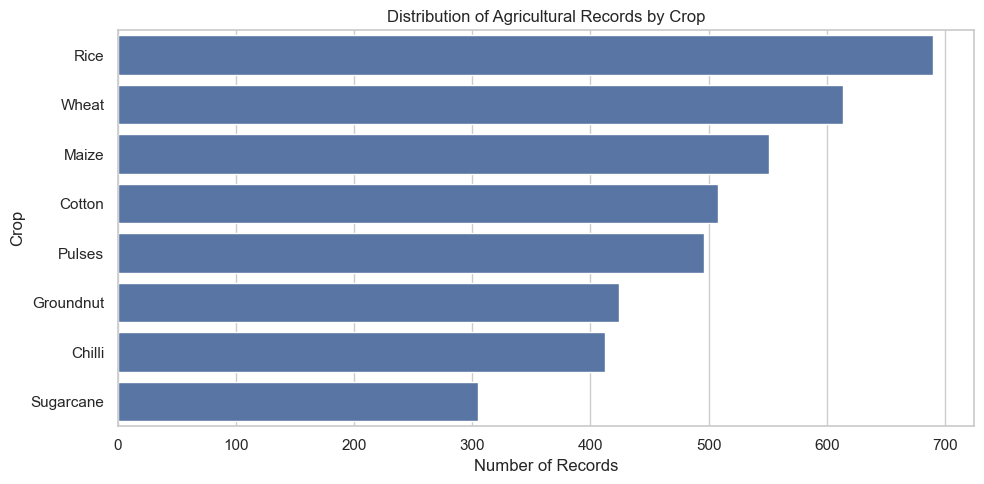

In [41]:
# Distribution of crops

crop_counts = data["Crop"].value_counts()

display(crop_counts.to_frame("Number of Records"))

plt.figure(figsize=(10, 5))

sns.countplot(
    data=data,
    y="Crop",
    order=crop_counts.index
)

plt.title("Distribution of Agricultural Records by Crop")
plt.xlabel("Number of Records")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

,Number of Records
State,
Andhra Pradesh,529
Telangana,516
Maharashtra,512
Madhya Pradesh,497
Karnataka,489
Gujarat,488
Tamil Nadu,485
Punjab,484


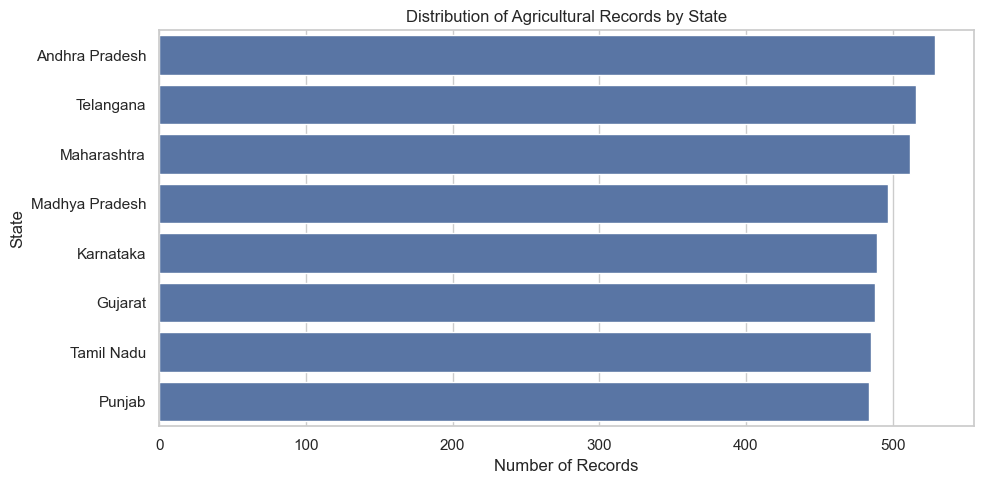

In [42]:
# Distribution of states

state_counts = data["State"].value_counts()

display(state_counts.to_frame("Number of Records"))

plt.figure(figsize=(10, 5))

sns.countplot(
    data=data,
    y="State",
    order=state_counts.index
)

plt.title("Distribution of Agricultural Records by State")
plt.xlabel("Number of Records")
plt.ylabel("State")
plt.tight_layout()
plt.show()

,Number of Records
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


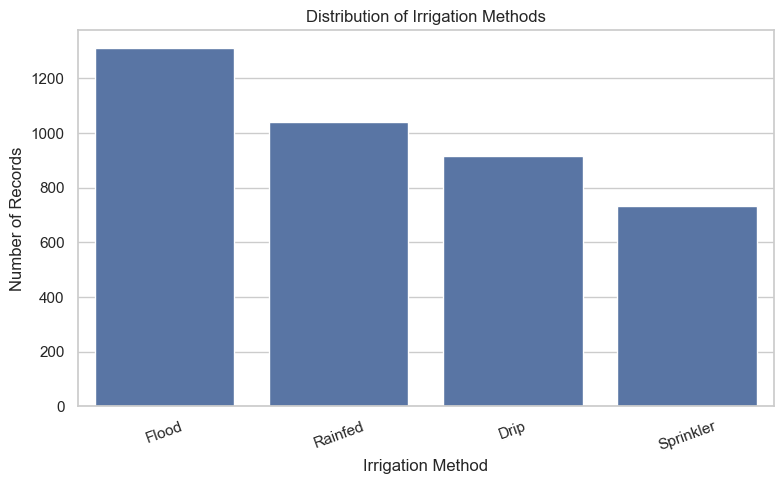

In [43]:
# Distribution of irrigation methods

irrigation_counts = data["Irrigation_Method"].value_counts()

display(irrigation_counts.to_frame("Number of Records"))

plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="Irrigation_Method",
    order=irrigation_counts.index
)

plt.title("Distribution of Irrigation Methods")
plt.xlabel("Irrigation Method")
plt.ylabel("Number of Records")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Seasonal agricultural performance

In [44]:
# Seasonal performance analysis

season_summary = data.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Production=("Production_Tonnes", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Cost=("Total_Cost_INR", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Rainfall=("Rainfall_mm", "mean"),
    Average_Water_Efficiency=(
        "Water_Efficiency_t_per_1000m3", "mean"
    ),
    Average_Disease_Risk=("Disease_Pest_Risk_pct", "mean"),
    Number_of_Records=("Farm_ID", "count")
).round(2)

display(season_summary)

,Average_Yield,Average_Production,Average_Revenue,Average_Cost,Average_Profit,Average_Rainfall,Average_Water_Efficiency,Average_Disease_Risk,Number_of_Records
Season,,,,,,,,,
Kharif,5.63,46.31,710719.06,531804.41,178914.65,849.20,5.89,54.47,1779
Rabi,5.04,41.49,601526.05,513836.58,87689.47,437.62,5.19,40.48,1627
Zaid,4.64,38.89,519171.90,543976.73,-24804.82,304.65,4.41,38.22,594


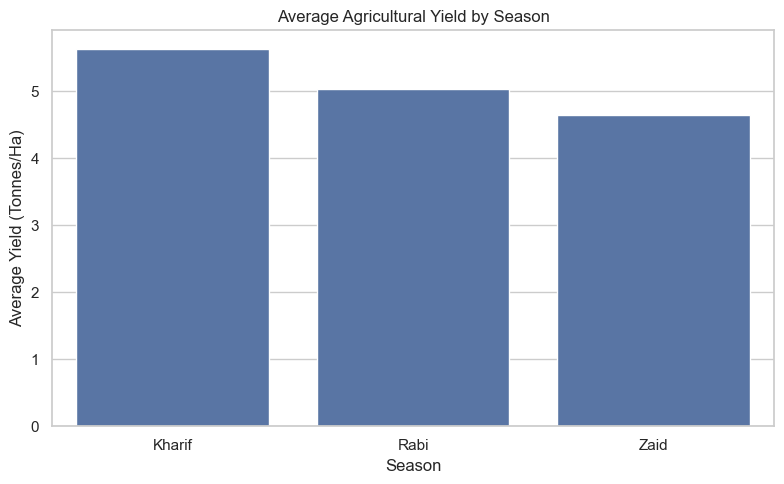

In [45]:
# Average yield across seasons

plt.figure(figsize=(8, 5))

sns.barplot(
    data=data,
    x="Season",
    y="Yield_Tonnes_Ha",
    estimator="mean",
    errorbar=None
)

plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

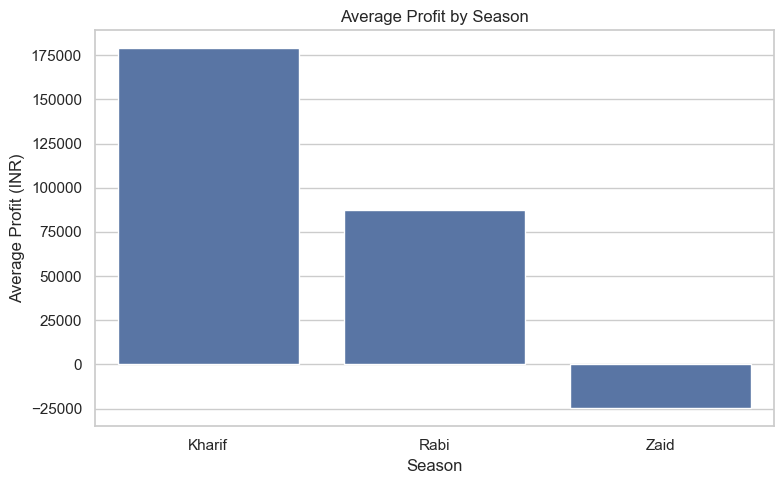

In [46]:
# Average profit across seasons

plt.figure(figsize=(8, 5))

sns.barplot(
    data=data,
    x="Season",
    y="Profit_INR",
    estimator="mean",
    errorbar=None
)

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

,Revenue_INR,Total_Cost_INR
Season,,
Kharif,710719.06,531804.41
Rabi,601526.05,513836.58
Zaid,519171.90,543976.73


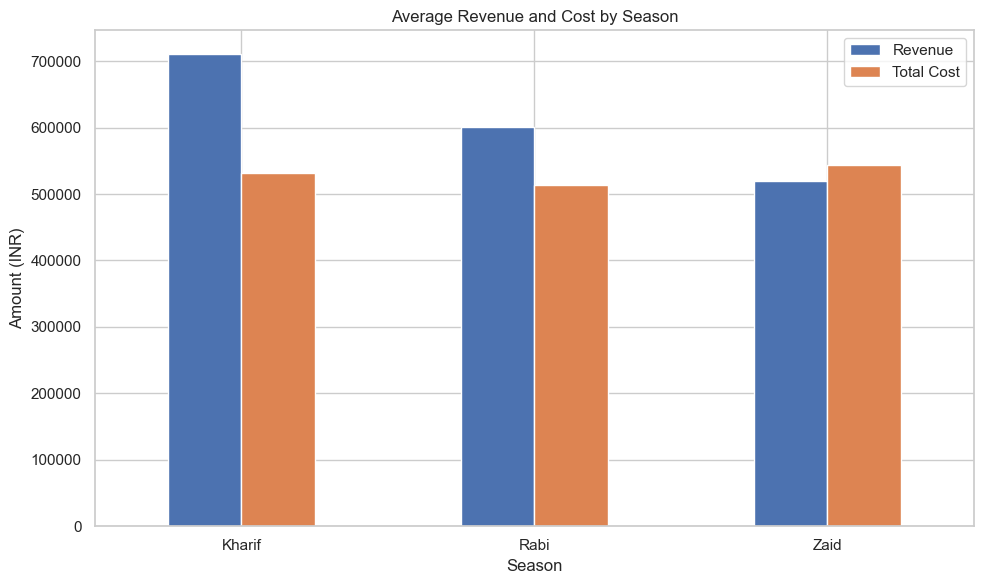

In [47]:
# Compare average revenue and cost across seasons

revenue_cost = data.groupby("Season")[
    ["Revenue_INR", "Total_Cost_INR"]
].mean()

display(revenue_cost.round(2))

revenue_cost.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Revenue and Cost by Season")
plt.xlabel("Season")
plt.ylabel("Amount (INR)")
plt.xticks(rotation=0)
plt.legend(["Revenue", "Total Cost"])
plt.tight_layout()
plt.show()

,Rainfall_mm,Temperature_C,Humidity_pct,Sunlight_Hours,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


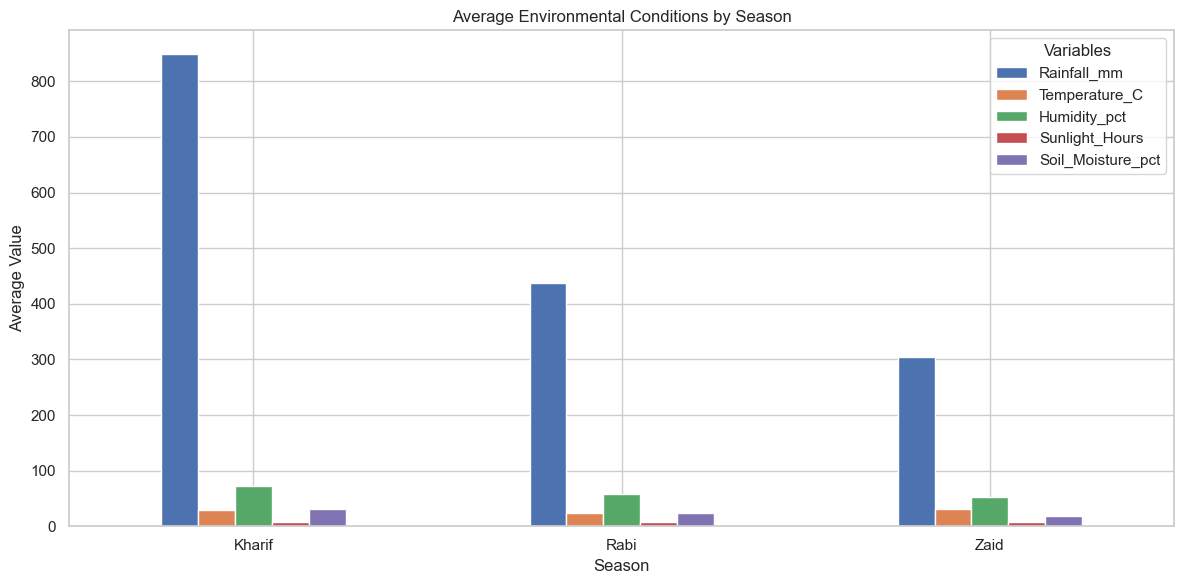

In [48]:
# Environmental conditions across seasons

environment_summary = data.groupby("Season").agg(
    Rainfall_mm=("Rainfall_mm", "mean"),
    Temperature_C=("Avg_Temperature_C", "mean"),
    Humidity_pct=("Humidity_pct", "mean"),
    Sunlight_Hours=("Sunlight_Hours_Day", "mean"),
    Soil_Moisture_pct=("Soil_Moisture_pct", "mean")
).round(2)

display(environment_summary)

environment_summary.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Environmental Conditions by Season")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Variables")
plt.tight_layout()
plt.show()

# Crop and state analysis

In [49]:
# Crop-wise performance analysis

crop_summary = data.groupby("Crop").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Production=("Production_Tonnes", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Cost=("Total_Cost_INR", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Efficiency=(
        "Water_Efficiency_t_per_1000m3", "mean"
    ),
    Number_of_Records=("Farm_ID", "count")
).sort_values(
    by="Average_Profit",
    ascending=False
).round(2)

display(crop_summary)

,Average_Yield,Average_Production,Average_Revenue,Average_Cost,Average_Profit,Average_Water_Efficiency,Number_of_Records
Crop,,,,,,,
Sugarcane,46.64,392.41,1371980.11,554792.13,817187.99,30.48,305
Chilli,1.54,12.38,1276777.23,525898.89,750878.34,2.95,412
Cotton,1.23,9.40,639423.08,514876.17,124546.92,1.94,508
Groundnut,1.32,9.66,542935.50,498077.38,44858.12,3.15,424
Pulses,0.92,7.40,528465.87,532703.92,-4238.05,2.90,496
Maize,2.71,21.78,457067.99,541046.32,-83978.33,5.60,551
Rice,2.43,19.29,423615.26,525828.76,-102213.50,1.95,690
Wheat,2.11,16.85,400104.89,523503.22,-123398.34,4.63,614


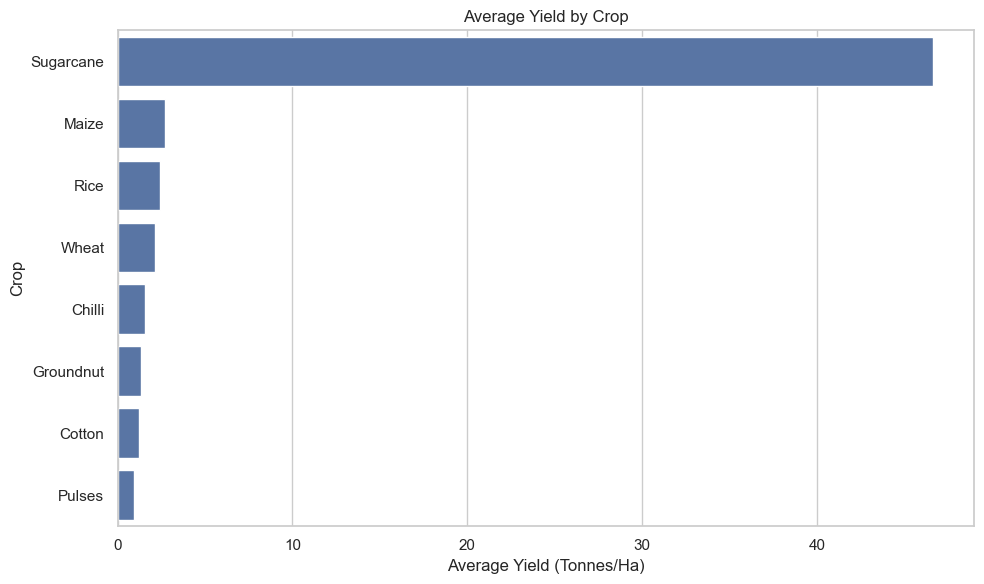

In [50]:
# Average yield by crop

crop_yield = crop_summary.sort_values(
    by="Average_Yield",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=crop_yield["Average_Yield"],
    y=crop_yield.index
)

plt.title("Average Yield by Crop")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

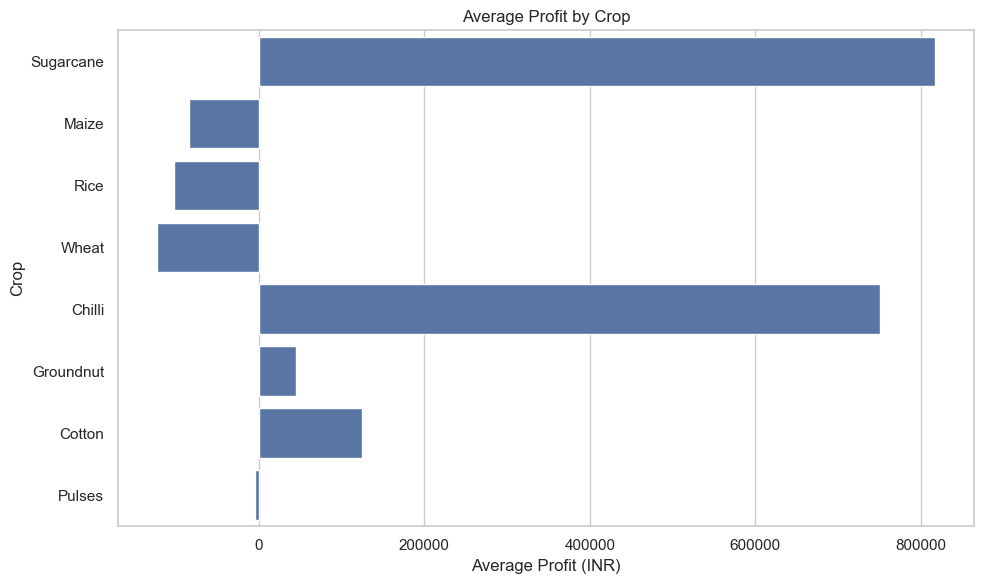

In [51]:
# Average profit by crop

plt.figure(figsize=(10, 6))

sns.barplot(
    x=crop_yield["Average_Profit"],
    y=crop_yield.index
)

plt.title("Average Profit by Crop")
plt.xlabel("Average Profit (INR)")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

In [52]:
# State-wise agricultural performance

state_summary = data.groupby("State").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Production=("Production_Tonnes", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Cost=("Total_Cost_INR", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Efficiency=(
        "Water_Efficiency_t_per_1000m3", "mean"
    ),
    Number_of_Records=("Farm_ID", "count")
).sort_values(
    by="Average_Yield",
    ascending=False
).round(2)

display(state_summary)

,Average_Yield,Average_Production,Average_Revenue,Average_Cost,Average_Profit,Average_Water_Efficiency,Number_of_Records
State,,,,,,,
Punjab,6.12,52.23,686225.70,550200.07,136025.64,5.62,484
Karnataka,5.69,47.73,653426.18,534003.85,119422.34,5.56,489
Gujarat,5.66,48.33,654692.86,537124.62,117568.24,5.58,488
Telangana,5.04,39.25,628784.53,519954.92,108829.62,5.46,516
Maharashtra,5.02,43.98,650032.67,514603.81,135428.86,5.28,512
Madhya Pradesh,4.99,37.56,597558.36,510717.60,86840.76,5.27,497
Tamil Nadu,4.88,40.84,629093.42,511348.67,117744.75,5.31,485
Andhra Pradesh,4.63,36.91,606663.66,533210.13,73453.53,5.03,529


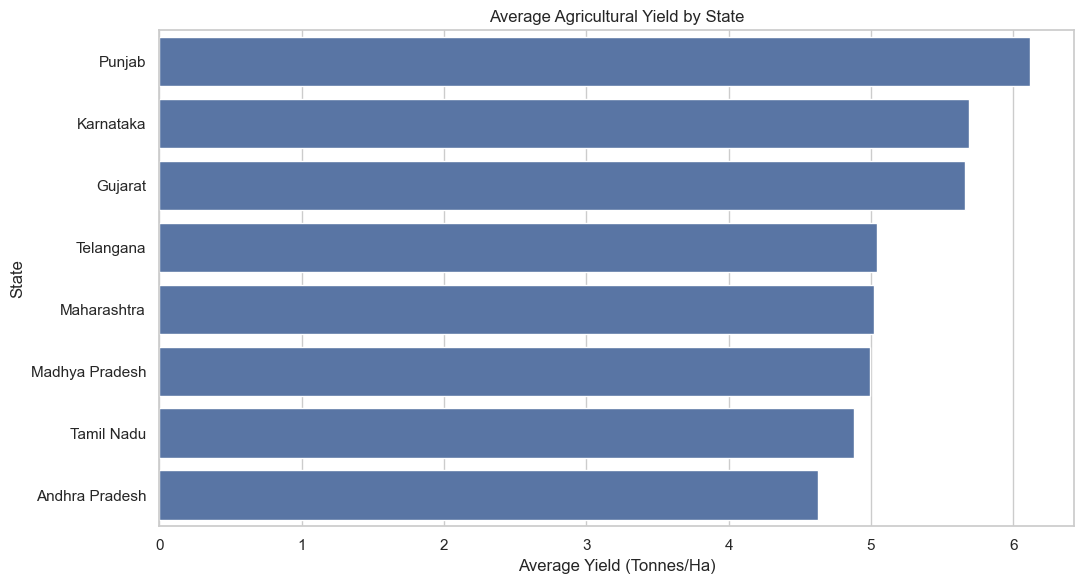

In [53]:
# Average yield by state

plt.figure(figsize=(11, 6))

sns.barplot(
    x=state_summary["Average_Yield"],
    y=state_summary.index
)

plt.title("Average Agricultural Yield by State")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


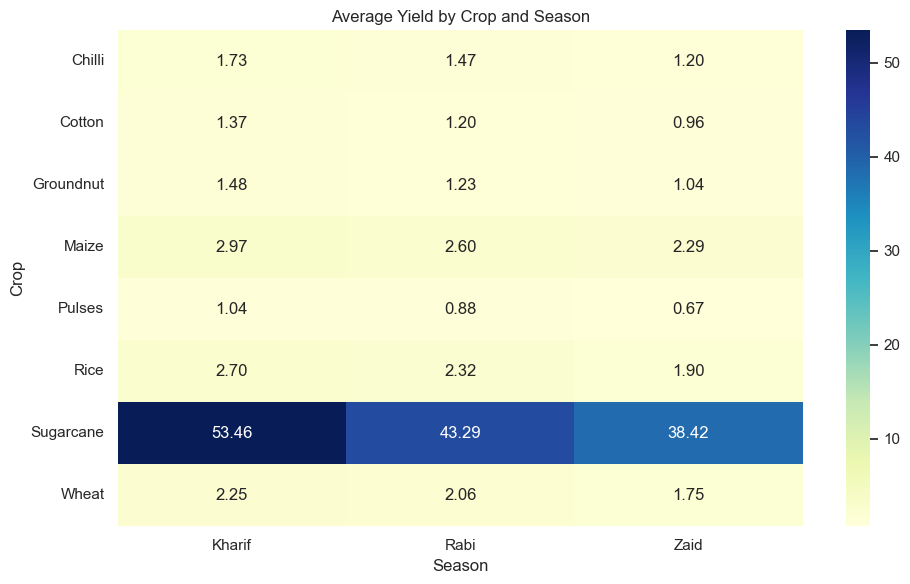

In [54]:
# Compare yield across seasons and crops

season_crop_yield = pd.pivot_table(
    data=data,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

display(season_crop_yield.round(2))

plt.figure(figsize=(10, 6))

sns.heatmap(
    season_crop_yield,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Yield by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

# Irrigation, resources and relationships

In [55]:
# Irrigation method comparison

irrigation_summary = data.groupby("Irrigation_Method").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=(
        "Water_Efficiency_t_per_1000m3", "mean"
    ),
    Average_Production=("Production_Tonnes", "mean"),
    Number_of_Records=("Farm_ID", "count")
).sort_values(
    by="Average_Yield",
    ascending=False
).round(2)

display(irrigation_summary)

,Average_Yield,Average_Profit,Average_Water_Used,Average_Water_Efficiency,Average_Production,Number_of_Records
Irrigation_Method,,,,,,
Drip,6.58,219626.00,5918.75,6.27,57.99,915
Sprinkler,5.16,91121.08,6208.26,4.67,42.34,734
Flood,4.86,73354.02,8026.47,3.44,38.73,1310
Rainfed,4.60,79050.37,3549.55,7.56,36.61,1041


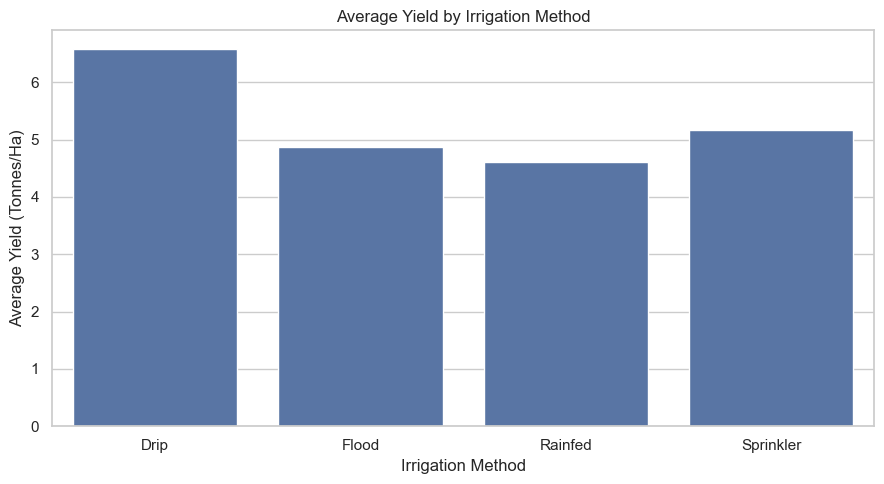

In [56]:
# Yield by irrigation method

plt.figure(figsize=(9, 5))

sns.barplot(
    data=data,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    estimator="mean",
    errorbar=None
)

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

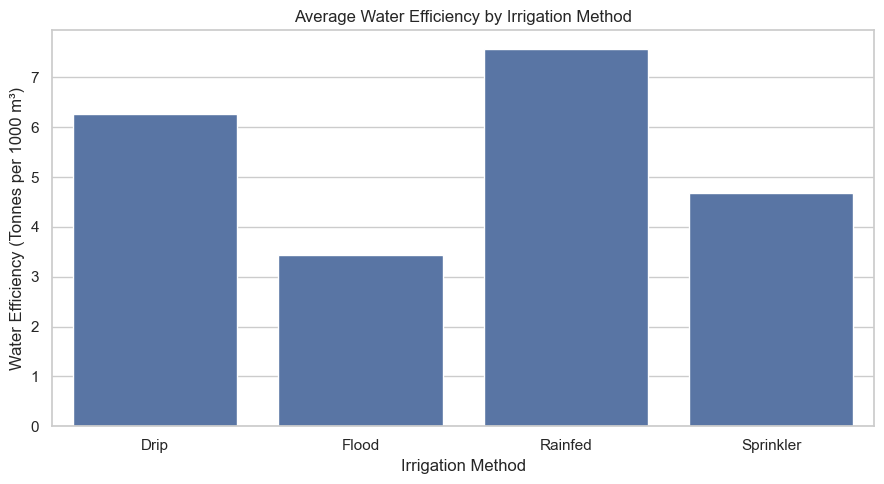

In [57]:
# Water efficiency comparison

plt.figure(figsize=(9, 5))

sns.barplot(
    data=data,
    x="Irrigation_Method",
    y="Water_Efficiency_t_per_1000m3",
    estimator="mean",
    errorbar=None
)

plt.title("Average Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency (Tonnes per 1000 m³)")
plt.tight_layout()
plt.show()

Correlation between fertilizer use and yield: 0.0


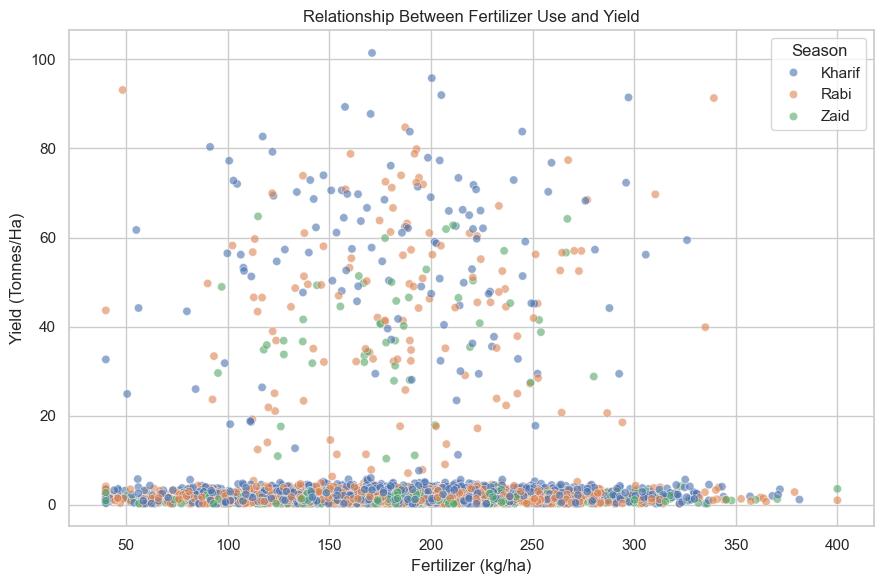

In [58]:
# Relationship between fertilizer use and yield

correlation_fertilizer = data[
    "Fertilizer_kg_ha"
].corr(data["Yield_Tonnes_Ha"])

print(
    "Correlation between fertilizer use and yield:",
    round(correlation_fertilizer, 4)
)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=data,
    x="Fertilizer_kg_ha",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.6
)

plt.title("Relationship Between Fertilizer Use and Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

Correlation between rainfall and yield: 0.031


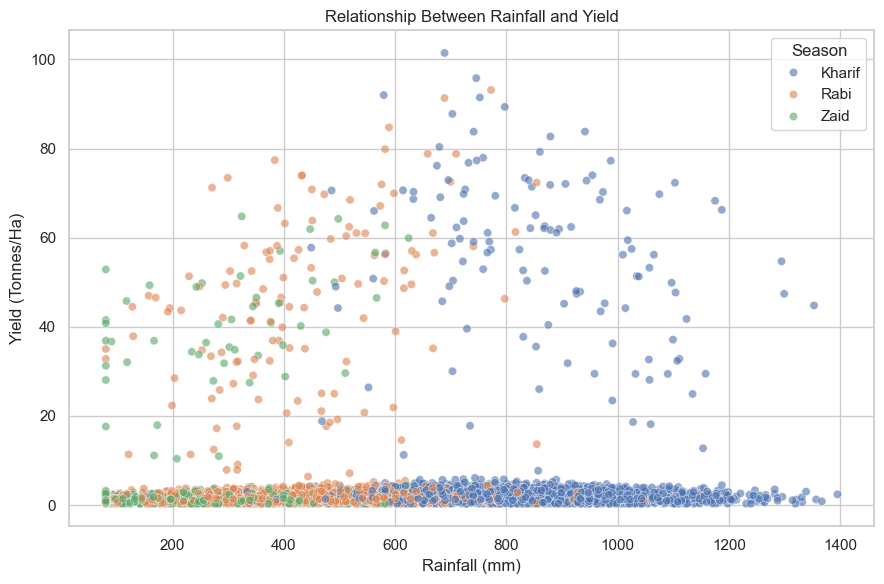

In [59]:
# Relationship between rainfall and yield

correlation_rainfall = data[
    "Rainfall_mm"
].corr(data["Yield_Tonnes_Ha"])

print(
    "Correlation between rainfall and yield:",
    round(correlation_rainfall, 4)
)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=data,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.6
)

plt.title("Relationship Between Rainfall and Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

,Average_Disease_Risk,Maximum_Disease_Risk,Minimum_Disease_Risk
Season,,,
Kharif,54.47,88.90,21.30
Rabi,40.48,71.20,5.10
Zaid,38.22,71.60,5.00


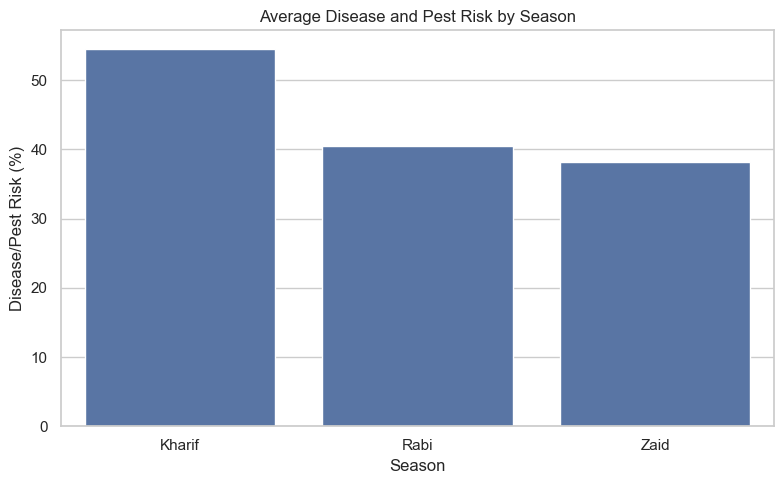

In [60]:
# Disease and pest risk across seasons

risk_summary = data.groupby("Season").agg(
    Average_Disease_Risk=("Disease_Pest_Risk_pct", "mean"),
    Maximum_Disease_Risk=("Disease_Pest_Risk_pct", "max"),
    Minimum_Disease_Risk=("Disease_Pest_Risk_pct", "min")
).round(2)

display(risk_summary)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=data,
    x="Season",
    y="Disease_Pest_Risk_pct",
    estimator="mean",
    errorbar=None
)

plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Disease/Pest Risk (%)")
plt.tight_layout()
plt.show()

## Statistical Analysis

### Purpose

Statistical tests are used to investigate whether
differences in agricultural yield across seasons
are statistically significant.

### Tests Applied

1. One-way ANOVA
2. Kruskal–Wallis test

### Hypotheses

**Null Hypothesis (H₀):**
The average agricultural yield is the same across seasons.

**Alternative Hypothesis (H₁):**
At least one season has a different yield distribution.

### Significance Level

Alpha = 0.05

If the p-value is less than 0.05, we reject H₀.
Otherwise, we do not reject H₀.

In [61]:
# Prepare yield data for statistical testing

season_groups = [
    group["Yield_Tonnes_Ha"].dropna().values
    for _, group in data.groupby("Season")
]

season_names = list(data["Season"].unique())

for name, group in zip(season_names, season_groups):
    print(name, ":", len(group), "observations")

Kharif : 1779 observations
Rabi : 1627 observations
Zaid : 594 observations


In [62]:
# One-way ANOVA

anova_stat, anova_p = stats.f_oneway(*season_groups)

print("One-way ANOVA Results")
print("--------------------")
print("F-statistic:", round(anova_stat, 4))
print("p-value:", round(anova_p, 6))

alpha = 0.05

if anova_p < alpha:
    print(
        "Conclusion: Reject H0. "
        "There is a statistically significant difference "
        "in mean yield across seasons."
    )
else:
    print(
        "Conclusion: Do not reject H0. "
        "There is insufficient evidence of a statistically "
        "significant difference in mean yield across seasons."
    )

One-way ANOVA Results
--------------------
F-statistic: 1.5439
p-value: 0.213678
Conclusion: Do not reject H0. There is insufficient evidence of a statistically significant difference in mean yield across seasons.


In [63]:
# Kruskal-Wallis test

kruskal_stat, kruskal_p = stats.kruskal(*season_groups)

print("Kruskal-Wallis Test Results")
print("---------------------------")
print("H-statistic:", round(kruskal_stat, 4))
print("p-value:", round(kruskal_p, 6))

if kruskal_p < alpha:
    print(
        "Conclusion: Reject H0. "
        "There is a statistically significant difference "
        "in yield distributions across seasons."
    )
else:
    print(
        "Conclusion: Do not reject H0. "
        "There is insufficient evidence of a statistically "
        "significant difference in yield distributions."
    )

Kruskal-Wallis Test Results
---------------------------
H-statistic: 68.7131
p-value: 0.0
Conclusion: Reject H0. There is a statistically significant difference in yield distributions across seasons.


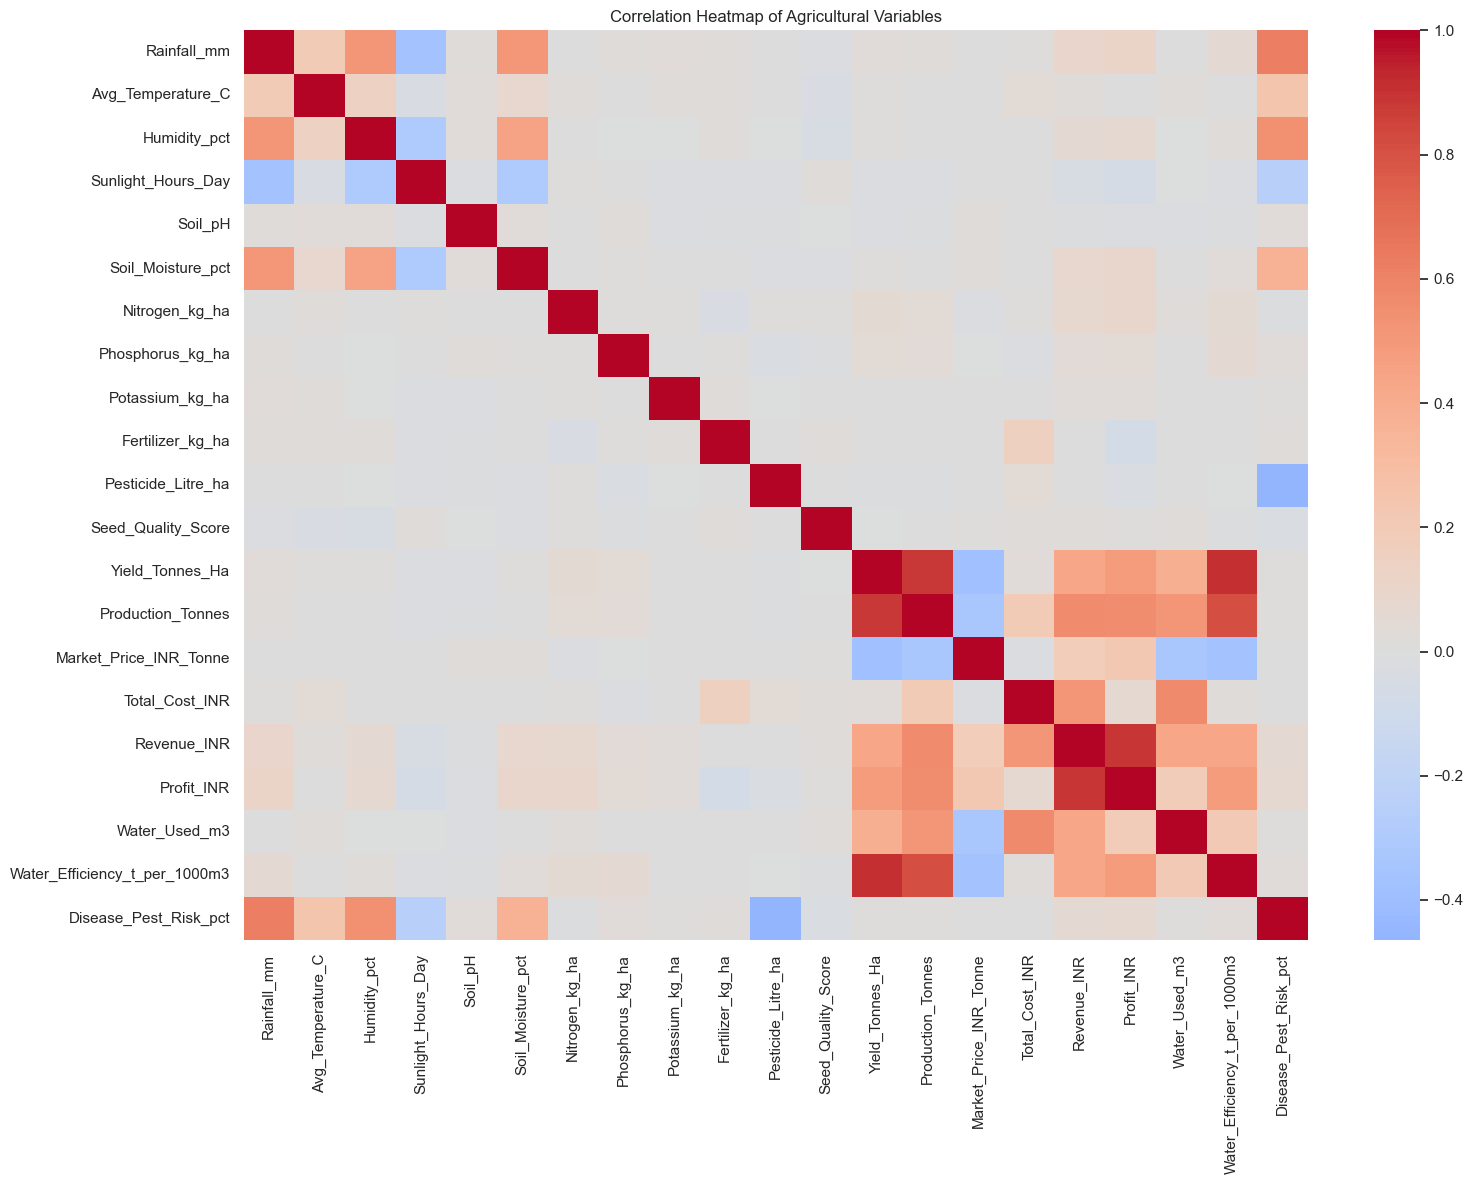

In [64]:
# Correlation analysis of numerical variables

correlation_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

correlation_matrix = data[correlation_columns].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Heatmap of Agricultural Variables")
plt.tight_layout()
plt.show()

In [65]:
# Identify variables most strongly associated with yield

yield_correlations = correlation_matrix[
    "Yield_Tonnes_Ha"
].sort_values(
    ascending=False
)

display(yield_correlations.to_frame("Correlation with Yield"))

,Correlation with Yield
Yield_Tonnes_Ha,1.00
Water_Efficiency_t_per_1000m3,0.91
Production_Tonnes,0.88
Profit_INR,0.49
Revenue_INR,0.43
Water_Used_m3,0.39
Nitrogen_kg_ha,0.05
Phosphorus_kg_ha,0.05
Rainfall_mm,0.03
Total_Cost_INR,0.03


In [66]:
# Generate evidence-based findings from the cleaned dataset

best_yield_season = season_summary["Average_Yield"].idxmax()
best_profit_season = season_summary["Average_Profit"].idxmax()
best_water_season = season_summary[
    "Average_Water_Efficiency"
].idxmax()

best_yield_crop = crop_summary["Average_Yield"].idxmax()
best_profit_crop = crop_summary["Average_Profit"].idxmax()

best_yield_state = state_summary["Average_Yield"].idxmax()
best_profit_state = state_summary["Average_Profit"].idxmax()

best_yield_irrigation = irrigation_summary[
    "Average_Yield"
].idxmax()

best_water_irrigation = irrigation_summary[
    "Average_Water_Efficiency"
].idxmax()

print("KEY FINDINGS")
print("=" * 60)

print(
    f"1. Highest average yield season: "
    f"{best_yield_season} "
    f"({season_summary.loc[best_yield_season, 'Average_Yield']:.2f} tonnes/ha)"
)

print(
    f"2. Highest average profit season: "
    f"{best_profit_season} "
    f"(INR {season_summary.loc[best_profit_season, 'Average_Profit']:,.2f})"
)

print(
    f"3. Highest average water efficiency season: "
    f"{best_water_season} "
    f"({season_summary.loc[best_water_season, 'Average_Water_Efficiency']:.2f})"
)

print(
    f"4. Highest average yield crop: "
    f"{best_yield_crop} "
    f"({crop_summary.loc[best_yield_crop, 'Average_Yield']:.2f} tonnes/ha)"
)

print(
    f"5. Highest average profit crop: "
    f"{best_profit_crop} "
    f"(INR {crop_summary.loc[best_profit_crop, 'Average_Profit']:,.2f})"
)

print(
    f"6. Highest average yield state: "
    f"{best_yield_state} "
    f"({state_summary.loc[best_yield_state, 'Average_Yield']:.2f} tonnes/ha)"
)

print(
    f"7. Highest average profit state: "
    f"{best_profit_state} "
    f"(INR {state_summary.loc[best_profit_state, 'Average_Profit']:,.2f})"
)

print(
    f"8. Highest average yield irrigation method: "
    f"{best_yield_irrigation}"
)

print(
    f"9. Highest average water efficiency irrigation method: "
    f"{best_water_irrigation}"
)

print(
    f"10. Fertilizer-yield correlation: "
    f"{correlation_fertilizer:.4f}"
)

print(
    f"11. Rainfall-yield correlation: "
    f"{correlation_rainfall:.4f}"
)

KEY FINDINGS
1. Highest average yield season: Kharif (5.63 tonnes/ha)
2. Highest average profit season: Kharif (INR 178,914.65)
3. Highest average water efficiency season: Kharif (5.89)
4. Highest average yield crop: Sugarcane (46.64 tonnes/ha)
5. Highest average profit crop: Sugarcane (INR 817,187.99)
6. Highest average yield state: Punjab (6.12 tonnes/ha)
7. Highest average profit state: Punjab (INR 136,025.64)
8. Highest average yield irrigation method: Drip
9. Highest average water efficiency irrigation method: Rainfed
10. Fertilizer-yield correlation: 0.0000
11. Rainfall-yield correlation: 0.0310


In [67]:
# Evidence-based recommendations

print("RECOMMENDATIONS")
print("=" * 60)

print(
    f"1. Seasonal Planning: "
    f"Consider {best_yield_season} for higher average yield, "
    f"while also considering crop type, cost, and risk."
)

print(
    f"2. Profit Planning: "
    f"Study the practices and crop mix associated with "
    f"{best_profit_season}, which has the highest average profit."
)

print(
    f"3. Crop Selection: "
    f"Investigate {best_yield_crop} for yield performance "
    f"and {best_profit_crop} for profit performance."
)

print(
    f"4. Irrigation Management: "
    f"Compare {best_yield_irrigation} for yield and "
    f"{best_water_irrigation} for water efficiency."
)

print(
    f"5. Resource Planning: "
    f"Use rainfall, soil moisture, fertilizer, and water "
    f"efficiency analysis to support resource allocation."
)

print(
    f"6. Risk Management: "
    f"Monitor disease and pest risk across seasons "
    f"before finalizing agricultural plans."
)

print(
    "7. Further Analysis: "
    "Use predictive analytics and optimization methods "
    "to improve agricultural decision-making."
)

print(
    "8. Caution: "
    "These findings describe associations in the dataset "
    "and should not be interpreted as causal proof."
)

RECOMMENDATIONS
1. Seasonal Planning: Consider Kharif for higher average yield, while also considering crop type, cost, and risk.
2. Profit Planning: Study the practices and crop mix associated with Kharif, which has the highest average profit.
3. Crop Selection: Investigate Sugarcane for yield performance and Sugarcane for profit performance.
4. Irrigation Management: Compare Drip for yield and Rainfed for water efficiency.
5. Resource Planning: Use rainfall, soil moisture, fertilizer, and water efficiency analysis to support resource allocation.
6. Risk Management: Monitor disease and pest risk across seasons before finalizing agricultural plans.
7. Further Analysis: Use predictive analytics and optimization methods to improve agricultural decision-making.
8. Caution: These findings describe associations in the dataset and should not be interpreted as causal proof.


## Conclusions

This project analyzed agricultural data across different
seasons, crops, states, irrigation methods, environmental
conditions, and economic indicators.

The analysis examined:

- Seasonal yield and profit variation.
- Crop-wise agricultural performance.
- State-wise agricultural performance.
- Irrigation and water efficiency.
- Environmental conditions.
- Relationships between fertilizer, rainfall, and yield.
- Disease and pest risk.
- Statistical differences in yield across seasons.

### Main Conclusion

Agricultural performance varies across different
seasonal and farming conditions.

The best-performing season, crop, state, and irrigation
method were identified using the calculated averages
from the dataset.

The statistical tests help determine whether observed
seasonal yield differences are statistically significant.

The findings can support better agricultural planning,
resource allocation, and future predictive analysis.

### Limitations

1. The dataset contains 4,000 records and 28 columns.
2. The analysis is based on the available dataset.
3. Correlation does not establish causation.
4. Statistical significance does not necessarily imply
   practical or economic significance.
5. Results may depend on crop mix, region, and other
   factors not fully controlled in this analysis.

## Future Scope

1. Develop an interactive dashboard using Power BI.
2. Apply machine learning for yield prediction.
3. Build seasonal agricultural forecasting models.
4. Analyze crop-specific resource requirements.
5. Develop an irrigation optimization model.
6. Study the relationship between cost, revenue,
   and profit in greater detail.
7. Integrate real-time weather data.
8. Develop a decision-support system for farmers.
9. Apply advanced statistical and machine learning
   methods for agricultural planning.
10. Extend the analysis with larger real-world datasets.

In [68]:
# Export important summary tables to an Excel file

output_file = "Seasonal_Agriculture_Analysis_Results.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    season_summary.to_excel(
        writer,
        sheet_name="Season Summary"
    )

    crop_summary.to_excel(
        writer,
        sheet_name="Crop Summary"
    )

    state_summary.to_excel(
        writer,
        sheet_name="State Summary"
    )

    irrigation_summary.to_excel(
        writer,
        sheet_name="Irrigation Summary"
    )

    environment_summary.to_excel(
        writer,
        sheet_name="Environment Summary"
    )

    correlation_matrix.to_excel(
        writer,
        sheet_name="Correlation Matrix"
    )

print("Results exported successfully!")
print("File name:", output_file)

Results exported successfully!
File name: Seasonal_Agriculture_Analysis_Results.xlsx


In [69]:
# Final project verification

print("=" * 60)
print("FINAL PROJECT VERIFICATION")
print("=" * 60)

print("Dataset shape:", data.shape)
print("Missing values:", data.isnull().sum().sum())
print("Duplicate rows:", data.duplicated().sum())

print("\nSeasons:", data["Season"].nunique())
print("Crops:", data["Crop"].nunique())
print("States:", data["State"].nunique())
print("Irrigation methods:", data["Irrigation_Method"].nunique())

print("\nProject analysis completed successfully.")
print("All major sections executed.")

FINAL PROJECT VERIFICATION
Dataset shape: (4000, 28)
Missing values: 0
Duplicate rows: 0

Seasons: 3
Crops: 8
States: 8
Irrigation methods: 4

Project analysis completed successfully.
All major sections executed.
